In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import utils.comparison_utils as cmp
import utils.visualization as viz

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
        "savefig.dpi": 300,
    },
)
plt.close("all")

SPLIT_PATHS_BY_RESOLUTION = {
    "mid_res": {
        "train": "../output/segmentation/8.final_results/mid_res/2026-04-30_14-33-37",
        "val": "../output/segmentation/8.final_results/mid_res/2026-04-30_13-24-40",
        "test": "../output/segmentation/8.final_results/mid_res/2026-04-19_09-10-35",
    },
    "high_res": {
        "train": "../output/segmentation/8.final_results/high_res/2026-04-21_08-42-13",
        "val": "../output/segmentation/8.final_results/high_res/2026-04-21_08-42-13",
        "test": "../output/segmentation/8.final_results/high_res/2026-04-28_14-28-44",
    },
}

VALID_SPLITS = ("train", "val", "test")

# Resultados Testes - Subsets

## Carregamento de dados

### Dados de train, test e validação

In [5]:
subset_rows = []
for resolution, split_paths in SPLIT_PATHS_BY_RESOLUTION.items():
    for subset_name in VALID_SPLITS:
        metadata = cmp.load_split_metadata(SPLIT_PATHS_BY_RESOLUTION, resolution, subset_name)
        summary_df = cmp.load_split_summary(SPLIT_PATHS_BY_RESOLUTION, resolution, subset_name)

        if metadata is None or summary_df is None:
            subset_rows.append(
                {
                    "subset": subset_name,
                    "resolution": resolution,
                    "num_images": np.nan,
                    "mean_dice": np.nan,
                    "mean_dice_correct": np.nan,
                    "mean_dice_all": np.nan,
                    "execution_time_min": np.nan,
                    "total_success_percent": np.nan,
                    "total_ostia_success": np.nan,
                    "is_available": False,
                }
            )
            continue

        execution_time_seconds = cmp.get_execution_time_seconds(metadata)
        num_images = cmp.get_num_images(metadata)
        total_success_percent = cmp.get_total_success_percent(metadata)

        dice_all = pd.to_numeric(summary_df["dice_artery"], errors="coerce")
        dice_all = dice_all.dropna()
        mean_dice_all = dice_all.mean() if not dice_all.empty else np.nan

        if {"both_correct", "both_tolerable"}.issubset(summary_df.columns):
            correct_mask = (
                summary_df["both_correct"].fillna(False).astype(bool)
                | summary_df["both_tolerable"].fillna(False).astype(bool)
            )
        elif "ostia_status" in summary_df.columns:
            correct_mask = summary_df["ostia_status"].isin(["both_correct", "both_tolerable"])
        else:
            status_series = summary_df.get("status", pd.Series(index=summary_df.index))
            correct_mask = status_series.isin(["ambos corretos", "ambos toleráveis"])

        dice_correct = pd.to_numeric(
            summary_df.loc[correct_mask, "dice_artery"],
            errors="coerce",
        ).dropna()
        mean_dice_correct = dice_correct.mean() if not dice_correct.empty else np.nan

        if pd.notna(num_images) and pd.notna(total_success_percent):
            total_ostia_success = (num_images * 2) * (total_success_percent / 100)
        else:
            total_ostia_success = np.nan

        subset_rows.append(
            {
                "subset": subset_name,
                "resolution": resolution,
                "num_images": num_images,
                "mean_dice": mean_dice_correct,
                "mean_dice_correct": mean_dice_correct,
                "mean_dice_all": mean_dice_all,
                "execution_time_min": execution_time_seconds / 60 if pd.notna(execution_time_seconds) else np.nan,
                "total_success_percent": total_success_percent,
                "total_ostia_success": total_ostia_success,
                "is_available": True,
            }
        )

subset_summary_df = pd.DataFrame(subset_rows)
subset_summary_df["subset"] = pd.Categorical(subset_summary_df["subset"], categories=list(VALID_SPLITS), ordered=True)
subset_summary_df = subset_summary_df.sort_values(["subset", "resolution"])

# Backward-compatible aliases for existing plotting helpers.
subset_summary_df["resolucao"] = subset_summary_df["resolution"]
subset_summary_df["num_imagens"] = subset_summary_df["num_images"]
subset_summary_df["dice_medio"] = subset_summary_df["mean_dice"]
subset_summary_df["dice_medio_correto"] = subset_summary_df["mean_dice_correct"]
subset_summary_df["dice_medio_todos"] = subset_summary_df["mean_dice_all"]
subset_summary_df["tempo_execucao_min"] = subset_summary_df["execution_time_min"]
subset_summary_df["sucesso_total_percent"] = subset_summary_df["total_success_percent"]
subset_summary_df["ostios_sucesso_total"] = subset_summary_df["total_ostia_success"]
subset_summary_df["disponivel"] = subset_summary_df["is_available"]

display(subset_summary_df)

missing_rows = subset_summary_df[~subset_summary_df["is_available"]]
if not missing_rows.empty:
    print("Combinations without data:")
    display(missing_rows[["subset", "resolution"]])


,subset,resolution,num_images,mean_dice,mean_dice_correct,mean_dice_all,execution_time_min,total_success_percent,total_ostia_success,is_available,resolucao,num_imagens,dice_medio,dice_medio_correto,dice_medio_todos,tempo_execucao_min,sucesso_total_percent,ostios_sucesso_total,disponivel
3,train,high_res,270,0.559050,0.559050,0.480714,2105.619854,72.222222,390.0,True,high_res,270,0.559050,0.559050,0.480714,2105.619854,72.222222,390.0,True
0,train,mid_res,270,0.613290,0.613290,0.552771,579.963033,82.592593,446.0,True,mid_res,270,0.613290,0.613290,0.552771,579.963033,82.592593,446.0,True
4,val,high_res,30,0.567802,0.567802,0.559032,230.129208,90.000000,54.0,True,high_res,30,0.567802,0.567802,0.559032,230.129208,90.000000,54.0,True
1,val,mid_res,30,0.643452,0.643452,0.603404,65.680854,90.000000,54.0,True,mid_res,30,0.643452,0.643452,0.603404,65.680854,90.000000,54.0,True
5,test,high_res,700,0.550288,0.550288,0.468436,5331.471496,71.428571,1000.0,True,high_res,700,0.550288,0.550288,0.468436,5331.471496,71.428571,1000.0,True
2,test,mid_res,700,0.607369,0.607369,0.555361,1077.879431,84.285714,1180.0,True,mid_res,700,0.607369,0.607369,0.555361,1077.879431,84.285714,1180.0,True


## Resultados por subset: val, train e test

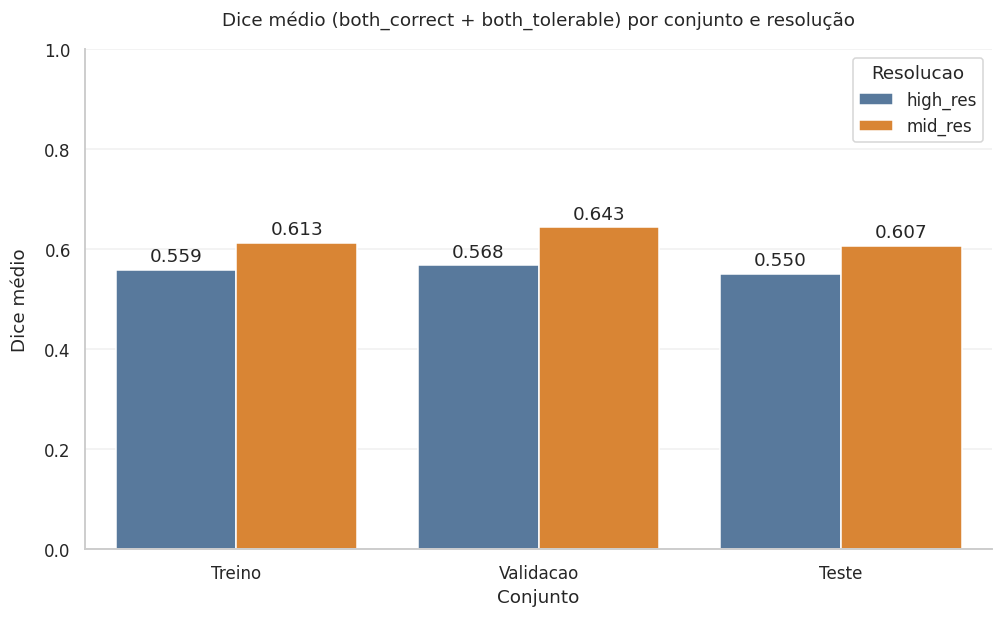

In [13]:
ax_subset = viz.plot_subset_metric_by_resolution(
    subset_summary_df=subset_summary_df,
    metric_col="dice_medio_correto",
    title="Dice médio (both_correct + both_tolerable) por conjunto e resolução",
    ylabel="Dice médio",
    palette=["#4C78A8", "#F58518"],
    ylim=(0, 1),
    bar_label_fmt="%.3f",
)

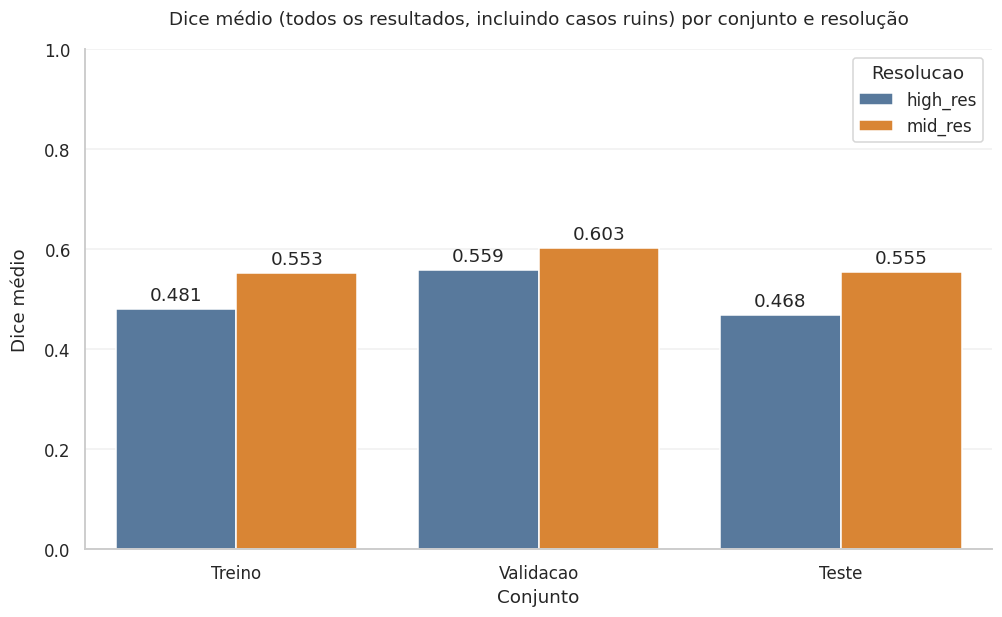

In [14]:
ax_subset_all = viz.plot_subset_metric_by_resolution(
    subset_summary_df=subset_summary_df,
    metric_col="dice_medio_todos",
    title="Dice médio (todos os resultados, incluindo casos ruins) por conjunto e resolução",
    ylabel="Dice médio",
    palette=["#4C78A8", "#F58518"],
    ylim=(0, 1),
    bar_label_fmt="%.3f",
)

### Impacto dos casos ruins no Dice

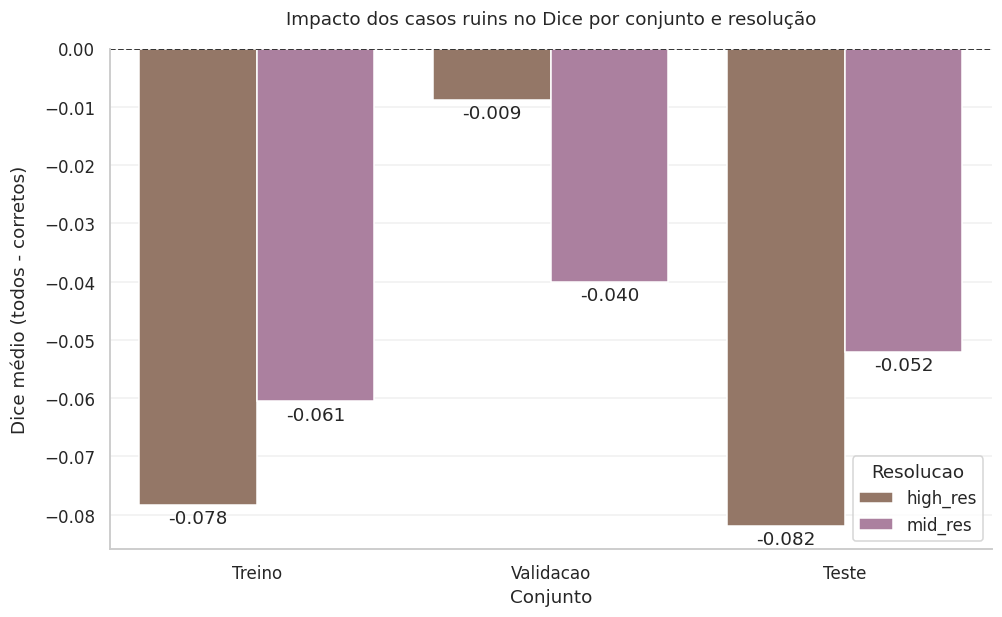

In [15]:
subset_summary_df["delta_dice"] = (
    subset_summary_df["dice_medio_todos"] - subset_summary_df["dice_medio_correto"]
)

ax_subset_delta = viz.plot_subset_metric_by_resolution(
    subset_summary_df=subset_summary_df,
    metric_col="delta_dice",
    title="Impacto dos casos ruins no Dice por conjunto e resolução",
    ylabel="Dice médio (todos - corretos)",
    palette=["#9C755F", "#B279A2"],
    hline_y=0,
    bar_label_fmt="%.3f",
)

### Tempo de execução por conjunto

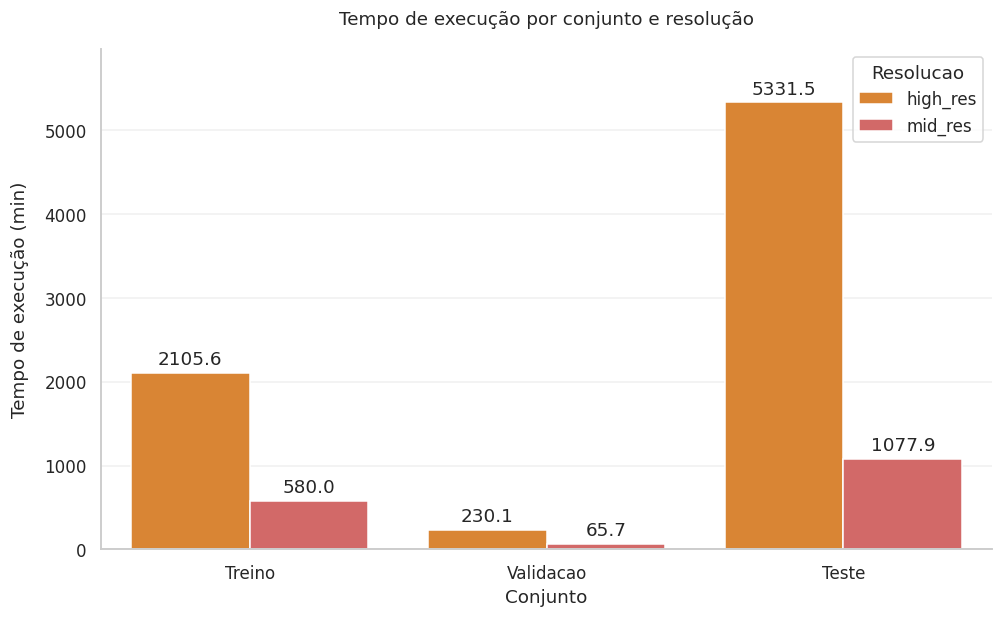

In [16]:
ax_subset_time = viz.plot_subset_execution_time_by_resolution(
    subset_summary_df=subset_summary_df,
    palette=["#F58518", "#E45756"],
)

### Percentual de óstios detectados com sucesso por conjunto

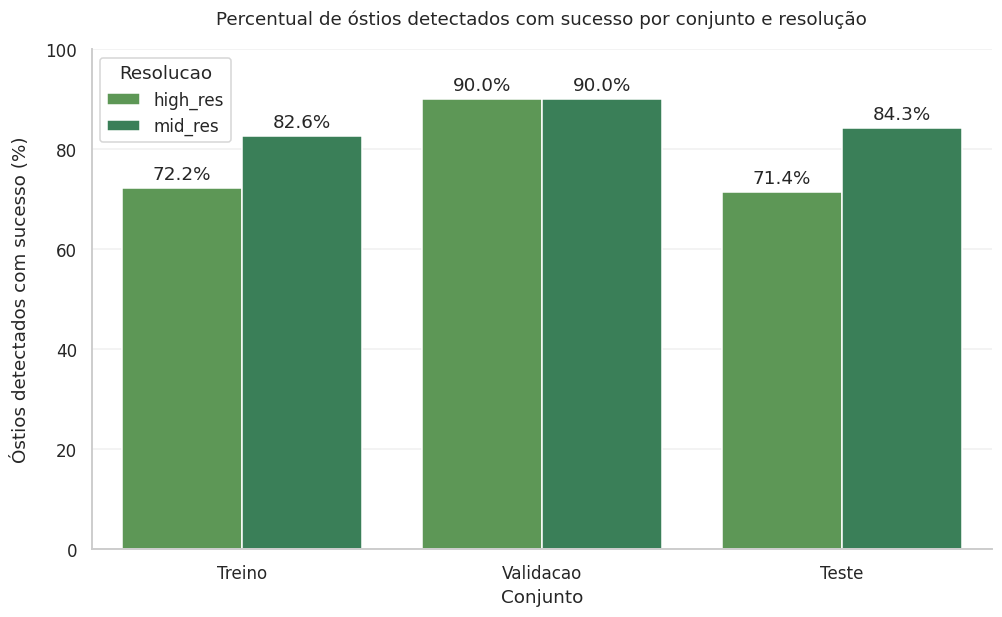

In [17]:
ax_subset_success = viz.plot_subset_ostia_success_by_resolution(
    subset_summary_df=subset_summary_df,
    palette=["#54A24B", "#2E8B57"],
)